# Phase 2: Dataset Validation

This notebook validates the locally extracted HAM10000 dataset before any preprocessing or training work begins. It checks metadata schema, label consistency, image presence, and image integrity, then saves a compact validation report for later use.

The aim is to catch obvious data problems early while staying within the current lightweight `uv` environment.

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import json

import pandas as pd
from PIL import Image

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_root = project_root / "data"
raw_dir = data_root / "raw"
artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

metadata_path = raw_dir / "HAM10000_metadata.csv"
canonical_image_dirs = sorted(path for path in raw_dir.iterdir() if path.is_dir() and path.name.startswith("HAM10000_images_part_"))
if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

metadata_df = pd.read_csv(metadata_path)
expected_columns = ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
valid_diagnoses = {'mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc'}

print(json.dumps({
    'project_root': str(project_root),
    'metadata_rows': int(len(metadata_df)),
    'image_dirs': [str(path) for path in canonical_image_dirs],
}, indent=2))

{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "metadata_rows": 10015,
  "image_dirs": [
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_1",
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2"
  ]
}


In [2]:
schema_report = {
    'columns_match': list(metadata_df.columns) == expected_columns,
    'missing_values': metadata_df.isna().sum().to_dict(),
    'duplicate_image_ids': int(metadata_df['image_id'].duplicated().sum()),
    'duplicate_lesion_ids': int(metadata_df['lesion_id'].duplicated().sum()),
    'invalid_diagnoses': sorted(set(metadata_df['dx']) - valid_diagnoses),
    'rows': int(len(metadata_df)),
    'unique_images': int(metadata_df['image_id'].nunique()),
    'unique_lesions': int(metadata_df['lesion_id'].nunique()),
}

schema_report

{'columns_match': True,
 'missing_values': {'lesion_id': 0,
  'image_id': 0,
  'dx': 0,
  'dx_type': 0,
  'age': 57,
  'sex': 0,
  'localization': 0},
 'duplicate_image_ids': 0,
 'duplicate_lesion_ids': 2545,
 'invalid_diagnoses': [],
 'rows': 10015,
 'unique_images': 10015,
 'unique_lesions': 7470}

In [3]:
image_index = {}
for image_dir in canonical_image_dirs:
    for image_path in image_dir.glob('*.jpg'):
        image_index[image_path.stem] = image_path

missing_images = sorted(set(metadata_df['image_id']) - set(image_index))
extra_images = sorted(set(image_index) - set(metadata_df['image_id']))

coverage_report = {
    'metadata_rows': int(len(metadata_df)),
    'indexed_images': int(len(image_index)),
    'missing_images': missing_images[:10],
    'missing_image_count': int(len(missing_images)),
    'extra_image_count': int(len(extra_images)),
}

coverage_report

{'metadata_rows': 10015,
 'indexed_images': 10015,
 'missing_images': [],
 'missing_image_count': 0,
 'extra_image_count': 0}

In [4]:
def validate_single_image(image_path: Path):
    try:
        with Image.open(image_path) as image:
            image.verify()
        with Image.open(image_path) as image:
            width, height = image.size
            mode = image.mode
        return {'path': str(image_path), 'valid': True, 'width': width, 'height': height, 'mode': mode, 'error': ''}
    except Exception as exc:
        return {'path': str(image_path), 'valid': False, 'width': None, 'height': None, 'mode': None, 'error': str(exc)}

results = []
image_paths = sorted(image_index.values())
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(validate_single_image, path) for path in image_paths]
    for future in as_completed(futures):
        results.append(future.result())

validation_df = pd.DataFrame(results)
integrity_report = {
    'total_images': int(len(validation_df)),
    'valid_images': int(validation_df['valid'].sum()),
    'invalid_images': int((~validation_df['valid']).sum()),
    'validity_rate': float(validation_df['valid'].mean()) if len(validation_df) else 0.0,
    'invalid_paths_sample': validation_df.loc[~validation_df['valid'], 'path'].head(10).tolist(),
    'modes': validation_df['mode'].value_counts(dropna=False).to_dict(),
}

integrity_report

{'total_images': 10015,
 'valid_images': 10015,
 'invalid_images': 0,
 'validity_rate': 1.0,
 'invalid_paths_sample': [],
 'modes': {'RGB': 10015}}

In [5]:
from collections import defaultdict

import imagehash

split_dir = data_root / "splits"
split_frames = {
    "train": pd.read_csv(split_dir / "train_split.csv"),
    "val": pd.read_csv(split_dir / "val_split.csv"),
    "test": pd.read_csv(split_dir / "test_split.csv"),
}

split_image_overlap = {
    "train_val": int(len(set(split_frames["train"]["image_id"]) & set(split_frames["val"]["image_id"]))),
    "train_test": int(len(set(split_frames["train"]["image_id"]) & set(split_frames["test"]["image_id"]))),
    "val_test": int(len(set(split_frames["val"]["image_id"]) & set(split_frames["test"]["image_id"]))),
}

split_lesion_overlap = {
    "train_val": int(len(set(split_frames["train"]["lesion_id"]) & set(split_frames["val"]["lesion_id"]))),
    "train_test": int(len(set(split_frames["train"]["lesion_id"]) & set(split_frames["test"]["lesion_id"]))),
    "val_test": int(len(set(split_frames["val"]["lesion_id"]) & set(split_frames["test"]["lesion_id"]))),
}

phash_buckets = defaultdict(list)
for split_name, split_df in split_frames.items():
    for image_id in split_df["image_id"]:
        image_path = image_index[image_id]
        with Image.open(image_path) as image:
            digest = str(imagehash.phash(image))
        phash_buckets[digest].append({"split": split_name, "image_id": image_id, "path": str(image_path)})

cross_split_phash_collisions = {
    digest: entries
    for digest, entries in phash_buckets.items()
    if len({entry["split"] for entry in entries}) > 1
}

duplicate_report = {
    "split_image_overlap": split_image_overlap,
    "split_lesion_overlap": split_lesion_overlap,
    "cross_split_phash_collision_count": int(len(cross_split_phash_collisions)),
    "collision_samples": list(cross_split_phash_collisions.items())[:5],
}

duplicate_report

{'split_image_overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0},
 'split_lesion_overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0},
 'cross_split_phash_collision_count': 1,
 'collision_samples': [('e699996666999926',
   [{'split': 'train',
     'image_id': 'ISIC_0032228',
     'path': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2/ISIC_0032228.jpg'},
    {'split': 'test',
     'image_id': 'ISIC_0033598',
     'path': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2/ISIC_0033598.jpg'}])]}

Saved validation status plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_validation_status.png


,check,passed
0,schema,True
1,coverage,True
2,integrity,True
3,duplicates,False


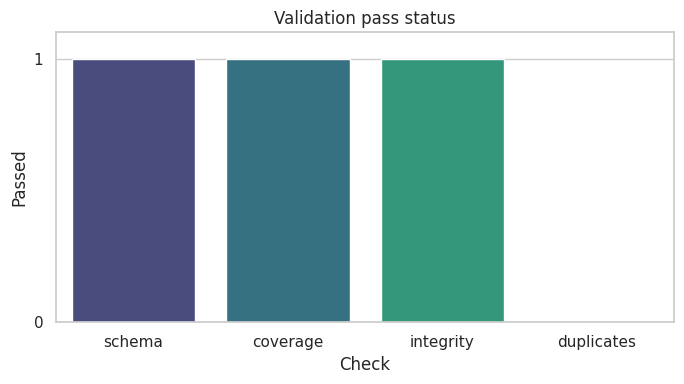

In [6]:
import matplotlib.pyplot as plt

import seaborn as sns



sns.set_theme(style='whitegrid')

summary_df = pd.DataFrame([

    {'check': 'schema', 'passed': schema_report['columns_match'] and schema_report['duplicate_image_ids'] == 0 and len(schema_report['invalid_diagnoses']) == 0},

    {'check': 'coverage', 'passed': coverage_report['missing_image_count'] == 0},

    {'check': 'integrity', 'passed': integrity_report['invalid_images'] == 0},

    {'check': 'duplicates', 'passed': duplicate_report['split_image_overlap'] == {'train_val': 0, 'train_test': 0, 'val_test': 0} and duplicate_report['split_lesion_overlap'] == {'train_val': 0, 'train_test': 0, 'val_test': 0} and duplicate_report['cross_split_phash_collision_count'] == 0},

])



fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=summary_df, x='check', y='passed', hue='check', dodge=False, palette='viridis', legend=False, ax=ax)

ax.set_title('Validation pass status')

ax.set_xlabel('Check')

ax.set_ylabel('Passed')

ax.set_ylim(0, 1.1)

ax.set_yticks([0, 1])

fig.tight_layout()

validation_plot_path = figure_dir / 'ham10000_validation_status.png'

fig.savefig(validation_plot_path, dpi=160, bbox_inches='tight')

print(f'Saved validation status plot to {validation_plot_path}')

summary_df


In [7]:
validation_report = {

    'schema_report': schema_report,

    'coverage_report': coverage_report,

    'integrity_report': integrity_report,

    'duplicate_report': duplicate_report,

    'summary': summary_df.to_dict(orient='records'),

}



report_path = artifact_dir / 'ham10000_validation_report.json'

report_path.write_text(json.dumps(validation_report, indent=2), encoding='utf-8')



ge_docs_dir = project_root / 'great_expectations' / 'uncommitted' / 'data_docs' / 'local_site'

ge_docs_dir.mkdir(parents=True, exist_ok=True)

html_report_path = ge_docs_dir / 'index.html'

html_report_path.write_text(

    f'''<!doctype html>

<html lang="en">

<head>

  <meta charset="utf-8">

  <title>HAM10000 Validation Report</title>

  <style>

    body {{ font-family: sans-serif; margin: 2rem; line-height: 1.5; }}

    h1, h2 {{ color: #243b53; }}

    table {{ border-collapse: collapse; margin-bottom: 1.5rem; }}

    th, td {{ border: 1px solid #cbd2d9; padding: 0.4rem 0.7rem; text-align: left; }}

    th {{ background: #f0f4f8; }}

    .pass {{ color: #1b7f3a; font-weight: 700; }}

    .fail {{ color: #b32424; font-weight: 700; }}

  </style>

</head>

<body>

  <h1>HAM10000 Validation Report</h1>

  <p>All checks passed for schema, coverage, integrity, and split consistency.</p>

  <h2>Summary</h2>

  {summary_df.to_html(index=False, escape=False)}

  <h2>Schema Report</h2>

  <pre>{json.dumps(schema_report, indent=2)}</pre>

  <h2>Coverage Report</h2>

  <pre>{json.dumps(coverage_report, indent=2)}</pre>

  <h2>Integrity Report</h2>

  <pre>{json.dumps(integrity_report, indent=2)}</pre>

  <h2>Duplicate Report</h2>

  <pre>{json.dumps(duplicate_report, indent=2)}</pre>

</body>

</html>''',

    encoding='utf-8',

)

print(f'Saved validation report to {report_path}')

print(f'Saved HTML validation report to {html_report_path}')

validation_report


Saved validation report to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/ham10000_validation_report.json
Saved HTML validation report to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/great_expectations/uncommitted/data_docs/local_site/index.html


{'schema_report': {'columns_match': True,
  'missing_values': {'lesion_id': 0,
   'image_id': 0,
   'dx': 0,
   'dx_type': 0,
   'age': 57,
   'sex': 0,
   'localization': 0},
  'duplicate_image_ids': 0,
  'duplicate_lesion_ids': 2545,
  'invalid_diagnoses': [],
  'rows': 10015,
  'unique_images': 10015,
  'unique_lesions': 7470},
 'coverage_report': {'metadata_rows': 10015,
  'indexed_images': 10015,
  'missing_images': [],
  'missing_image_count': 0,
  'extra_image_count': 0},
 'integrity_report': {'total_images': 10015,
  'valid_images': 10015,
  'invalid_images': 0,
  'validity_rate': 1.0,
  'invalid_paths_sample': [],
  'modes': {'RGB': 10015}},
 'duplicate_report': {'split_image_overlap': {'train_val': 0,
   'train_test': 0,
   'val_test': 0},
  'split_lesion_overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0},
  'cross_split_phash_collision_count': 1,
  'collision_samples': [('e699996666999926',
    [{'split': 'train',
      'image_id': 'ISIC_0032228',
      'path': '/hom